# QPSK & 16-QAM Digital Modulation Simulator

This notebook simulates two digital modulation schemes — QPSK and 16-QAM — commonly used in wireless communication systems (including 4G/5G). It models the full transmission chain: bit generation → modulation → AWGN noise channel → demodulation → error analysis.

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Set a seed so results are reproducible while you're testing
np.random.seed(42)

# Step 1: Generate random binary data
num_bits = 1000  # start small, we'll scale up later
bits = np.random.randint(0, 2, num_bits)

print("First 20 bits:", bits[:20])
print("Total bits generated:", len(bits))

First 20 bits: [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0]
Total bits generated: 1000


## 1. Generate Random Bits and Map to QPSK Symbols
Random binary data is generated, then grouped into pairs of bits. Each pair is mapped to one of 4 QPSK symbols using Gray coding, represented as complex numbers (I + jQ).

In [19]:
# Step 2: Group bits into pairs and map to QPSK symbols
# Reshape bits into pairs
bit_pairs = bits.reshape(-1, 2)

# Mapping table (Gray coded)
mapping = {
    (0, 0): (1 + 1j),
    (0, 1): (-1 + 1j),
    (1, 1): (-1 - 1j),
    (1, 0): (1 - 1j)
}

# Convert each bit pair to a complex symbol
symbols = np.array([mapping[tuple(pair)] for pair in bit_pairs])

# Normalize energy (so average symbol power = 1)
symbols = symbols / np.sqrt(2)

print("First 5 bit pairs:", bit_pairs[:5])
print("First 5 QPSK symbols:", symbols[:5])

First 5 bit pairs: [[0 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]]
First 5 QPSK symbols: [-0.70710678+0.70710678j  0.70710678+0.70710678j -0.70710678+0.70710678j
  0.70710678+0.70710678j -0.70710678+0.70710678j]


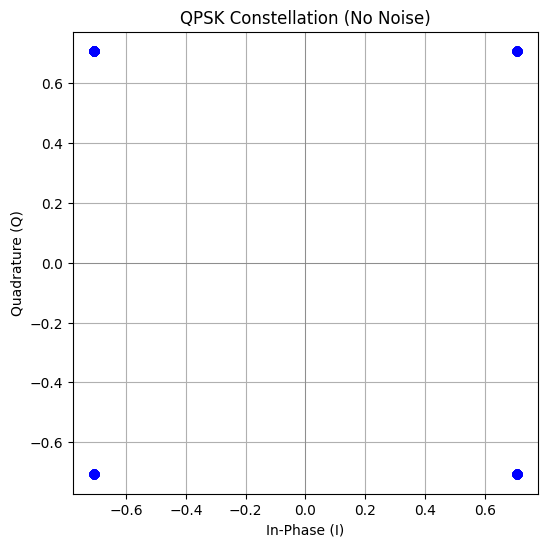

In [20]:
# Step 3: Plot the constellation diagram (before noise)
plt.figure(figsize=(6,6))
plt.scatter(symbols.real, symbols.imag, color='blue')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title("QPSK Constellation (No Noise)")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')
plt.show()

## 2. Simulate AWGN Channel
Real wireless channels introduce noise. Here, Additive White Gaussian Noise (AWGN) is added to the transmitted symbols based on a target Signal-to-Noise Ratio (SNR), simulating real-world signal degradation.

In [21]:
# Step 4: Add AWGN (Additive White Gaussian Noise)

def add_awgn_noise(symbols, snr_db):
    """
    Adds Gaussian noise to symbols based on desired SNR (in dB)
    """
    # Convert SNR from dB to linear scale
    snr_linear = 10 ** (snr_db / 10)

    # Calculate signal power (average power of symbols)
    signal_power = np.mean(np.abs(symbols) ** 2)

    # Calculate required noise power
    noise_power = signal_power / snr_linear

    # Generate complex Gaussian noise (real + imaginary parts)
    noise = np.sqrt(noise_power / 2) * (np.random.randn(len(symbols)) + 1j * np.random.randn(len(symbols)))

    # Add noise to the clean signal
    noisy_symbols = symbols + noise

    return noisy_symbols

# Test it at a specific SNR value
test_snr_db = 10  # try 10 dB first — moderate noise
noisy_symbols = add_awgn_noise(symbols, test_snr_db)

print("First 5 clean symbols:", symbols[:5])
print("First 5 noisy symbols:", noisy_symbols[:5])

First 5 clean symbols: [-0.70710678+0.70710678j  0.70710678+0.70710678j -0.70710678+0.70710678j
  0.70710678+0.70710678j -0.70710678+0.70710678j]
First 5 noisy symbols: [-0.63068782+0.83767709j  1.12663133+0.62676663j -0.49458555+0.83918122j
  0.5781072 +0.95502044j -0.90799841+0.89057217j]


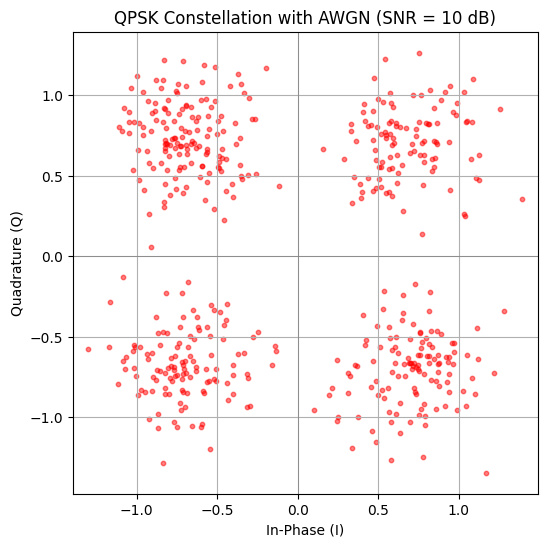

In [22]:
# Step 5: Plot noisy constellation
plt.figure(figsize=(6,6))
plt.scatter(noisy_symbols.real, noisy_symbols.imag, color='red', alpha=0.5, s=10)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.title(f"QPSK Constellation with AWGN (SNR = {test_snr_db} dB)")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')
plt.show()

## 3. Demodulate and Calculate Bit Error Rate (BER)
The receiver decides which symbol was sent based on the noisy signal, converts it back to bits, and compares against the original bits to calculate BER.

In [23]:
# Step 6: Demodulate - decide which symbol each noisy point is closest to

def demodulate_qpsk(noisy_symbols):
    """
    Decides the symbol based on which quadrant the noisy point falls in.
    QPSK decision is simple: just check the sign of I and Q.
    """
    demodulated_bits = []

    for sym in noisy_symbols:
        I = sym.real
        Q = sym.imag

        # Reverse the mapping based on sign of I and Q
        if I > 0 and Q > 0:
            demodulated_bits.append((0, 0))
        elif I < 0 and Q > 0:
            demodulated_bits.append((0, 1))
        elif I < 0 and Q < 0:
            demodulated_bits.append((1, 1))
        else:  # I > 0 and Q < 0
            demodulated_bits.append((1, 0))

    return np.array(demodulated_bits)

# Demodulate the noisy symbols from Step 4
received_bit_pairs = demodulate_qpsk(noisy_symbols)

# Flatten back into a single bit stream to compare with original
received_bits = received_bit_pairs.flatten()

print("First 10 original bits: ", bits[:10])
print("First 10 received bits: ", received_bits[:10])

First 10 original bits:  [0 1 0 0 0 1 0 0 0 1]
First 10 received bits:  [0 1 0 0 0 1 0 0 0 1]


In [24]:
# Step 7: Calculate Bit Error Rate (BER)

num_errors = np.sum(bits != received_bits)
ber = num_errors / len(bits)

print(f"Number of bit errors: {num_errors}")
print(f"Total bits: {len(bits)}")
print(f"BER at {test_snr_db} dB SNR: {ber}")

Number of bit errors: 0
Total bits: 1000
BER at 10 dB SNR: 0.0


## 4. BER vs SNR Analysis
The simulation is repeated across a range of SNR values to observe how error rate changes with channel quality — the standard way to evaluate a modulation scheme's performance.

In [25]:
# Step 8: BER vs SNR curve

def run_ber_simulation(snr_db_range, num_bits=100000):
    ber_results = []

    for snr_db in snr_db_range:
        # Generate fresh random bits for this SNR test
        bits = np.random.randint(0, 2, num_bits)
        bit_pairs = bits.reshape(-1, 2)
        symbols = np.array([mapping[tuple(pair)] for pair in bit_pairs]) / np.sqrt(2)

        # Add noise
        noisy_symbols = add_awgn_noise(symbols, snr_db)

        # Demodulate
        received_bit_pairs = demodulate_qpsk(noisy_symbols)
        received_bits = received_bit_pairs.flatten()

        # Calculate BER
        num_errors = np.sum(bits != received_bits)
        ber = num_errors / len(bits)
        ber_results.append(ber)

        print(f"SNR = {snr_db} dB -> BER = {ber:.6f}")

    return ber_results

# Run across a range of SNR values
snr_range_db = np.arange(0, 12, 1)
ber_values = run_ber_simulation(snr_range_db, num_bits=100000)

SNR = 0 dB -> BER = 0.158500
SNR = 1 dB -> BER = 0.132720
SNR = 2 dB -> BER = 0.105340
SNR = 3 dB -> BER = 0.079530
SNR = 4 dB -> BER = 0.056410
SNR = 5 dB -> BER = 0.037790
SNR = 6 dB -> BER = 0.023130
SNR = 7 dB -> BER = 0.012690
SNR = 8 dB -> BER = 0.006180
SNR = 9 dB -> BER = 0.002550
SNR = 10 dB -> BER = 0.000740
SNR = 11 dB -> BER = 0.000220


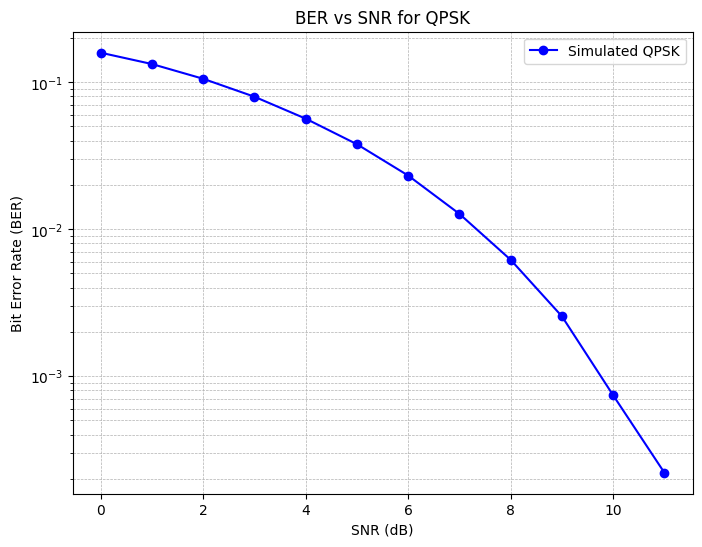

In [26]:
# Step 9: Plot BER vs SNR curve

plt.figure(figsize=(8,6))
plt.semilogy(snr_range_db, ber_values, marker='o', linestyle='-', color='blue', label='Simulated QPSK')
plt.title("BER vs SNR for QPSK")
plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## 5. Validation Against Theoretical BER Formula
Simulated results are compared against the theoretical QPSK BER formula to confirm correctness of the implementation.

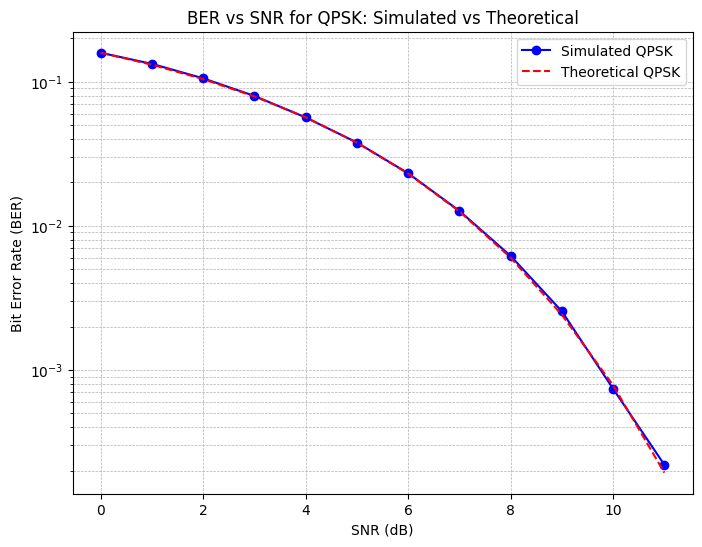

In [27]:
from scipy.special import erfc

# Theoretical QPSK BER formula
def theoretical_qpsk_ber(snr_db):
    snr_linear = 10 ** (snr_db / 10)
    eb_n0 = snr_linear/2
    return 0.5 * erfc(np.sqrt(eb_n0))

theoretical_ber = [theoretical_qpsk_ber(snr) for snr in snr_range_db]

plt.figure(figsize=(8,6))
plt.semilogy(snr_range_db, ber_values, marker='o', linestyle='-', color='blue', label='Simulated QPSK')
plt.semilogy(snr_range_db, theoretical_ber, linestyle='--', color='red', label='Theoretical QPSK')
plt.title("BER vs SNR for QPSK: Simulated vs Theoretical")
plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## 6. Extending to 16-QAM
16-QAM packs 4 bits per symbol (vs 2 for QPSK), enabling higher data rates but requiring higher SNR for the same error rate. This section implements and compares 16-QAM against QPSK.

In [28]:
# Step 10: 16-QAM constellation mapping

# 16-QAM uses 4 bits per symbol
# We'll use a standard Gray-coded 4x4 grid: I and Q each take values from {-3,-1,+1,+3}

def qam16_mapping():
    levels = [-3, -1, 1, 3]
    # Gray code order for 2 bits -> level index
    gray_order = {(0,0): -3, (0,1): -1, (1,1): 1, (1,0): 3}

    mapping_16qam = {}
    for i_bits, i_val in gray_order.items():
        for q_bits, q_val in gray_order.items():
            bits_4 = i_bits + q_bits  # combine into 4-bit tuple
            symbol = i_val + 1j * q_val
            mapping_16qam[bits_4] = symbol

    return mapping_16qam

mapping_16qam = qam16_mapping()

# Normalize average energy to 1
avg_energy = np.mean([abs(v)**2 for v in mapping_16qam.values()])
norm_factor = np.sqrt(avg_energy)

print("16-QAM mapping (before normalization):")
for k, v in list(mapping_16qam.items())[:4]:
    print(k, "->", v)
print(f"\nNormalization factor: {norm_factor:.4f}")

16-QAM mapping (before normalization):
(0, 0, 0, 0) -> (-3-3j)
(0, 0, 0, 1) -> (-3-1j)
(0, 0, 1, 1) -> (-3+1j)
(0, 0, 1, 0) -> (-3+3j)

Normalization factor: 3.1623


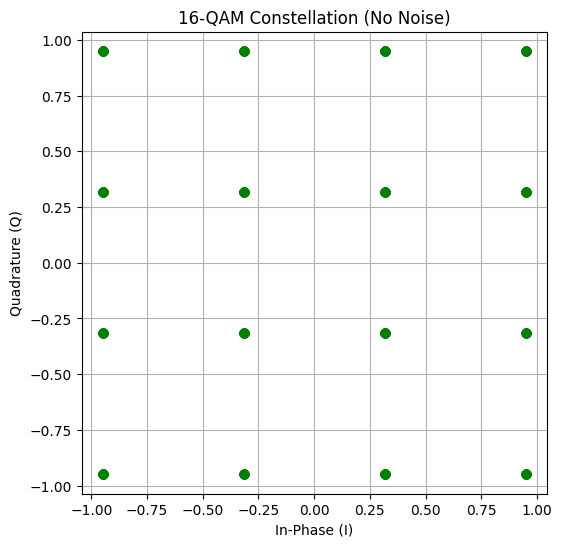

In [29]:
# Step 11: 16-QAM modulation function

def modulate_16qam(bits, mapping_16qam, norm_factor):
    bit_groups = bits.reshape(-1, 4)
    symbols = np.array([mapping_16qam[tuple(group)] for group in bit_groups]) / norm_factor
    return symbols

def demodulate_16qam(noisy_symbols, mapping_16qam, norm_factor):
    # Rebuild reverse mapping: symbol -> bits
    reverse_map = {v/norm_factor: k for k, v in mapping_16qam.items()}
    possible_symbols = np.array(list(reverse_map.keys()))

    demodulated_bits = []
    for sym in noisy_symbols:
        # Find closest constellation point (minimum distance decision)
        distances = np.abs(possible_symbols - sym)
        closest_symbol = possible_symbols[np.argmin(distances)]
        demodulated_bits.append(reverse_map[closest_symbol])

    return np.array(demodulated_bits)

# Quick test at one SNR value
test_bits_16qam = np.random.randint(0, 2, 4000)  # must be multiple of 4
test_symbols_16qam = modulate_16qam(test_bits_16qam, mapping_16qam, norm_factor)

# Visualize clean 16-QAM constellation
plt.figure(figsize=(6,6))
plt.scatter(test_symbols_16qam.real, test_symbols_16qam.imag, color='green')
plt.title("16-QAM Constellation (No Noise)")
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')
plt.show()

In [30]:
# Step 12: BER vs SNR simulation for 16-QAM

def run_ber_simulation_16qam(snr_db_range, num_bits=200000):
    ber_results_16qam = []

    # Ensure num_bits is a multiple of 4
    num_bits = (num_bits // 4) * 4

    for snr_db in snr_db_range:
        bits = np.random.randint(0, 2, num_bits)
        symbols = modulate_16qam(bits, mapping_16qam, norm_factor)

        noisy_symbols = add_awgn_noise(symbols, snr_db)

        received_bits = demodulate_16qam(noisy_symbols, mapping_16qam, norm_factor).flatten()

        num_errors = np.sum(bits != received_bits)
        ber = num_errors / len(bits)
        ber_results_16qam.append(ber)

        print(f"SNR = {snr_db} dB -> BER (16-QAM) = {ber:.6f}")

    return ber_results_16qam

# Use a wider SNR range since 16-QAM needs higher SNR for same BER as QPSK
snr_range_db_16qam = np.arange(0, 20, 1)
ber_values_16qam = run_ber_simulation_16qam(snr_range_db_16qam, num_bits=200000)

SNR = 0 dB -> BER (16-QAM) = 0.288840
SNR = 1 dB -> BER (16-QAM) = 0.262035
SNR = 2 dB -> BER (16-QAM) = 0.237120
SNR = 3 dB -> BER (16-QAM) = 0.212445
SNR = 4 dB -> BER (16-QAM) = 0.186995
SNR = 5 dB -> BER (16-QAM) = 0.163390
SNR = 6 dB -> BER (16-QAM) = 0.140955
SNR = 7 dB -> BER (16-QAM) = 0.119775
SNR = 8 dB -> BER (16-QAM) = 0.098065
SNR = 9 dB -> BER (16-QAM) = 0.077470
SNR = 10 dB -> BER (16-QAM) = 0.058825
SNR = 11 dB -> BER (16-QAM) = 0.042100
SNR = 12 dB -> BER (16-QAM) = 0.027980
SNR = 13 dB -> BER (16-QAM) = 0.017395
SNR = 14 dB -> BER (16-QAM) = 0.009455
SNR = 15 dB -> BER (16-QAM) = 0.004385
SNR = 16 dB -> BER (16-QAM) = 0.001785
SNR = 17 dB -> BER (16-QAM) = 0.000510
SNR = 18 dB -> BER (16-QAM) = 0.000180
SNR = 19 dB -> BER (16-QAM) = 0.000020


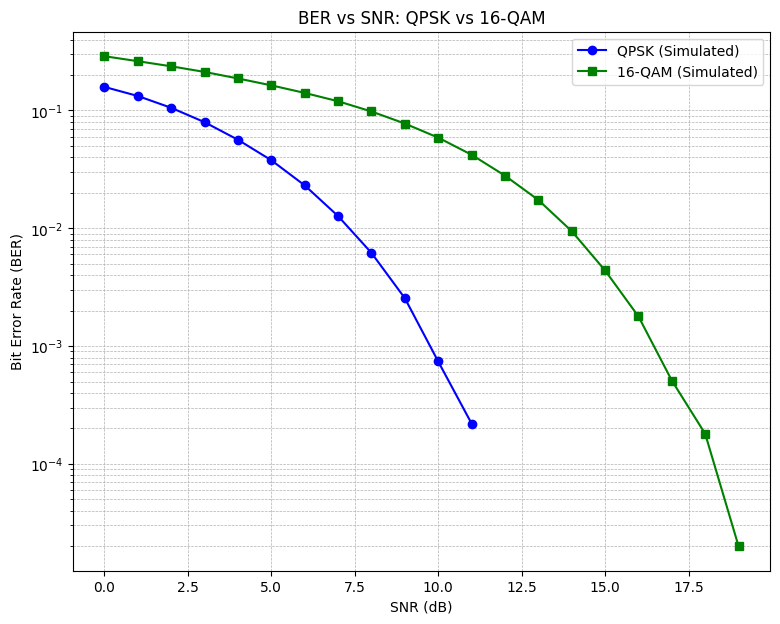

In [31]:
# Step 13: Compare QPSK vs 16-QAM

plt.figure(figsize=(9,7))
plt.semilogy(snr_range_db, ber_values, marker='o', linestyle='-', color='blue', label='QPSK (Simulated)')
plt.semilogy(snr_range_db_16qam, ber_values_16qam, marker='s', linestyle='-', color='green', label='16-QAM (Simulated)')
plt.title("BER vs SNR: QPSK vs 16-QAM")
plt.xlabel("SNR (dB)")
plt.ylabel("Bit Error Rate (BER)")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Conclusion
This simulation demonstrates the core tradeoff in digital modulation: higher-order schemes (16-QAM) achieve higher data throughput at the cost of requiring stronger signal quality (SNR) to maintain the same reliability as lower-order schemes (QPSK). This principle underlies adaptive modulation techniques used in real-world 4G/5G networks.